# 测试集结果评估

In [3]:
import pickle
import numpy as np
import polars as pl
from deeptan.utils.metrics import (
    compute_jsd,
    compute_mse,
    compute_pcc,
    ari_score,
    nmi_score,
    r2_score,
    f1_score,
    silhouette_score,
    roc_auc_score,
)

## Feature reconstruction

In [7]:
path_nmic = "/mnt/hdd2/homext/wuch/xn2p/data/raw_df/scRNA/SRP273996_split/nmic_g/split_seed_42_0.parquet.npz"
path_predicted_results = "/mnt/hdd1/wuch/logs/GSE155304_SRP273996/predicted_seed_42_20250212152331_170LZ/seed_42_tst_numpy.pkl"
path_x_true = "/mnt/hdd2/homext/wuch/xn2p/data/raw_df/scRNA/SRP273996_split/split_seed_42_2.parquet"

In [8]:
with open(
    path_predicted_results,
    "rb",
) as f:
    results = pickle.load(f)

x_pred = results["node_recon_all"]
# 删除x_pred的最后一个维度
x_pred = x_pred[:, :, 0]

nmic_results = np.load(path_nmic)
mat_feat_indices: np.ndarray = nmic_results["mat_feat_indices"]
x_true_o = pl.read_parquet(path_x_true)
# x_true = x_true_o.sort("obs_names").drop("obs_names")
x_true = x_true_o.drop("obs_names")

In [9]:
avail_colnames = [x_true.columns[i] for i in mat_feat_indices]
x_true = x_true[avail_colnames].to_numpy()
print("x_true shape:", x_true.shape)
print("x_pred shape:", x_pred.shape)

x_true shape: (1051, 3306)
x_pred shape: (1051, 3306)


In [11]:
# 计算 MSE
mse_values = compute_mse(x_true, x_pred)
print("MSE:", mse_values)

r2_ = r2_score(x_true, x_pred)
print("R2:", r2_)

# 计算 PCC
pcc_values = compute_pcc(x_true, x_pred)
print("PCC:", pcc_values)

# 计算 JSD
jsd_values = compute_jsd(x_true, x_pred)
print("JSD:", jsd_values)

NameError: name 'compute_mse' is not defined

## Read labels

In [13]:
label_pred = results["labels"]
# label被log_softmax后，需要exp后再计算
# label_pred = np.exp(label_pred)
print(label_pred.shape)
# print(label_pred)
# 每行的和应该为1
# print(np.sum(label_pred, axis=1))

# Sort predicted labels


(1051, 16)


In [14]:
# Read true labels
sample_names = x_true_o["obs_names"].to_list()
label_true = pl.read_parquet(
    "/mnt/hdd2/homext/wuch/xn2p/data/raw_df/scRNA/SRP273996_celltypes_onehot.parquet"
)
# Sort by barcode
label_true = label_true.filter(pl.col("bc").is_in(sample_names)).sort("bc")
# print(label_true)

tmp_label_pred = x_true_o.select("obs_names").hstack(pl.DataFrame(label_pred)).sort("obs_names")
# print(tmp_label_pred)

# Check if the order is correct
print(label_true["bc"].to_list() == tmp_label_pred["obs_names"].to_list())

obs_names = tmp_label_pred["obs_names"].to_list()

label_true = label_true.drop("bc").to_numpy()
label_pred = tmp_label_pred.drop("obs_names").to_numpy()

True


In [15]:
# 将每个分类的概率转换为one-hot编码
# label_true_onehot = np.eye(label_true.shape[1])[label_true.argmax(axis=1)]
# label_pred_onehot = np.eye(label_pred.shape[1])[label_pred.argmax(axis=1)]
# print(label_pred_onehot)
# print(label_true_onehot)

label_true_argmax = label_true.argmax(axis=1)
label_pred_argmax = label_pred.argmax(axis=1)
print(label_pred_argmax)
print(label_true_argmax)

label_pred_debug = label_true.argmax(axis=1)
# 随机打乱使label_pred_debug与label_true_argmax有65%一致
perc = 0.15
np.random.shuffle(label_pred_debug)
label_pred_debug[:int(len(label_pred_debug) * perc)] = label_true_argmax[:int(len(label_true_argmax) * perc)]
print(label_pred_debug)

# Calculate F1 score
f1_micro = f1_score(label_true_argmax, label_pred_argmax, average="micro")
print(f"F1-micro: {f1_micro}")
print(f"F1-micro debug: {f1_score(label_true_argmax, label_pred_debug, average="micro")}")
# f1_macro = f1_score(label_true_argmax, label_pred_argmax, average="macro")
# print(f"F1 macro: {f1_macro}")
# f1_weighted = f1_score(label_true_argmax, label_pred_argmax, average="weighted")
# print(f"F1 weighted: {f1_weighted}")

SyntaxError: f-string: unmatched '(' (2208301220.py, line 22)

In [16]:
nmi = nmi_score(label_true_argmax, label_pred_argmax)
print(f"NMI: {nmi}")
print(f"NMI debug: {nmi_score(label_true_argmax, label_pred_debug)}")

NameError: name 'nmi_score' is not defined

In [37]:
ari = ari_score(label_true_argmax, label_pred_argmax)
print(f"ARI: {ari}")
print(f"ARI debug: {ari_score(label_true_argmax, label_pred_debug)}")

ARI: 0.0
ARI debug: 0.2261518333828498


In [38]:
# auc = roc_auc_score(label_true, label_pred)
# print(f"AUC: {auc}")
_label_true = label_true.reshape(-1, 1)
_label_pred_debug = label_pred_debug.reshape(-1, 1)
print(f"AUC debug: {roc_auc_score(_label_true, _label_pred_debug)}")

ValueError: Found input variables with inconsistent numbers of samples: [16816, 1051]

#### ASW & kBET

In [1]:
import scanpy as sc
# from scib.metrics import kBET

In [2]:
path_adata = "/mnt/hdd2/homext/wuch/xn2p/data/raw_df/scRNA/SRP273996.h5ad"
adata = sc.read_h5ad(path_adata)
print(adata)
adata.obs["Orig_ident"] = adata.obs["Orig.ident"]
# print adata 'Orig.ident'
# print(adata.obs['Orig.ident'])

AnnData object with n_obs × n_vars = 10431 × 53678
    obs: 'Orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Percent.mt', 'Seurat_clusters', 'Celltype', 'Dataset', 'Tissue', 'Organ', 'Condition', 'Genotype', 'Libraries', 'ACE'
    var: 'features'
    obsm: 'X_umap'


In [ ]:
adata_tst = adata[obs_names]
print(adata_tst)

In [ ]:
# 计算 kBET
kbet_score = kBET(
    adata_tst,
    batch_key="Orig_ident",
    label_key="Celltype",
    embed="X_umap",  # 使用降维后的嵌入矩阵
    type_="embed",  # 可选 'full' 或 'embed'
)

print(f"kBET score: {kbet_score}")

0 labels consist of a single batch or is too small. Skip.


/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/scib/metrics/kbet.py:158: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() inst

kBET score: 0.9496


In [25]:
kbet_score = kBET(
    adata,
    batch_key="Orig_ident",
    label_key="Celltype",
    embed="X_umap",  # 使用降维后的嵌入矩阵
    type_="embed",  # 可选 'full' 或 'embed'
)

print(f"kBET score: {kbet_score}")

0 labels consist of a single batch or is too small. Skip.


/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/scib/metrics/kbet.py:158: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/scib/metrics/kbet.py:158: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local c

Adding diffusion to step 4
Adding diffusion to step 5
Adding diffusion to step 6
Adding diffusion to step 7
Adding diffusion to step 8
Adding diffusion to step 9


/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/scib/metrics/kbet.py:158: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


Adding diffusion to step 4
Adding diffusion to step 5


...

Adding diffusion to step 4
Adding diffusion to step 5


/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/scib/metrics/kbet.py:158: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/scib/metrics/kbet.py:158: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  

Adding diffusion to step 4


/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/scib/metrics/kbet.py:158: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/scib/metrics/kbet.py:158: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  

kBET score: 0.7362193447192408


In [18]:
# ASW
from scib.metrics import silhouette

# 计算 ASW
asw_score = silhouette(
    adata_tst,
    label_key="Celltype",  # 细胞类型标签
    embed="X_umap",  # 使用降维后的嵌入矩阵
    metric="euclidean",  # 距离度量，默认为欧几里得距离
)

print(f"ASW score: {asw_score}")

ASW score: 0.5650355487623632


In [19]:
asw_score = silhouette(
    adata,
    label_key="Celltype",  # 细胞类型标签
    embed="X_umap",  # 使用降维后的嵌入矩阵
    metric="euclidean",  # 距离度量，默认为欧几里得距离
)

print(f"ASW score: {asw_score}")

ASW score: 0.5545435626303704


## Read graph-level embeddings

### 可视化完整数据

In [4]:
%config InlineBackend.figure_format = 'retina'
%config InlineBackend.figure_dpi = 300

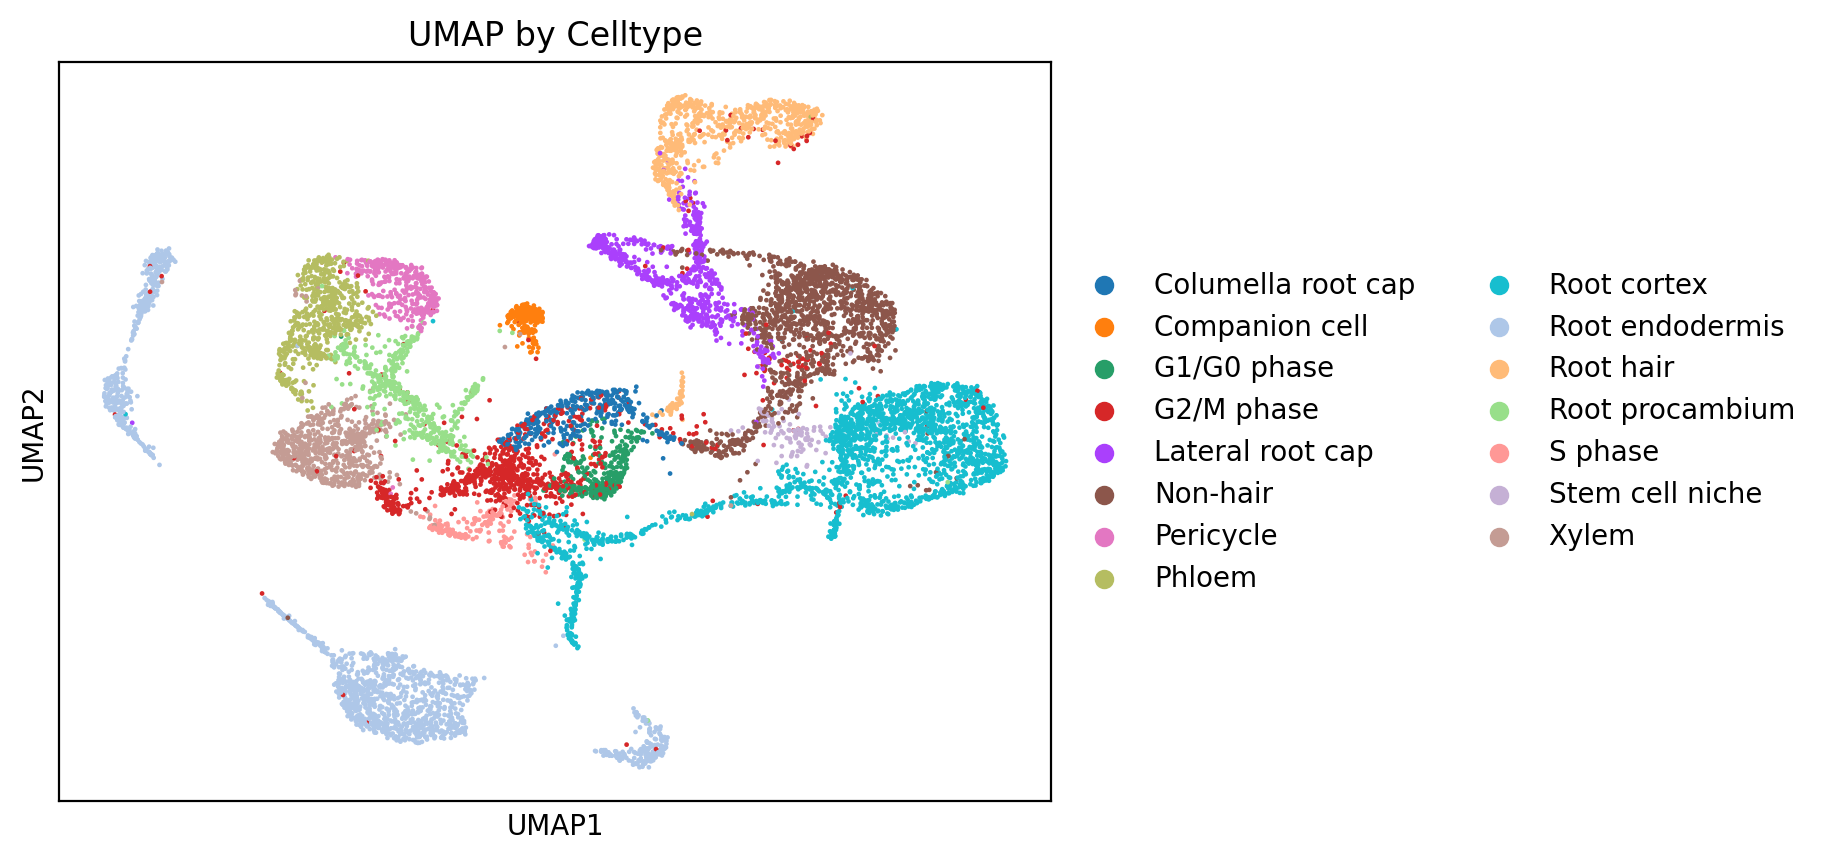

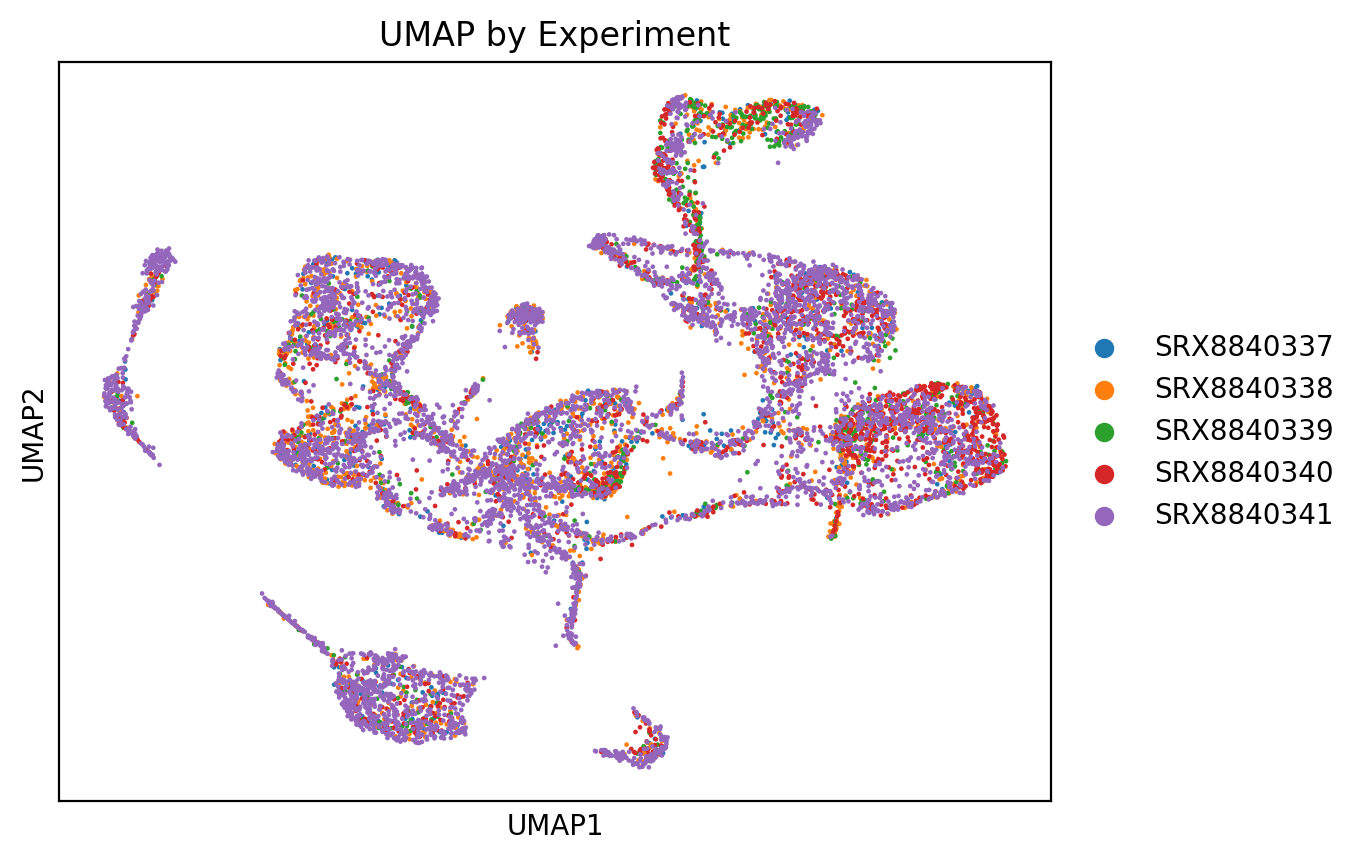

In [5]:
sc.pl.umap(adata, color="Celltype", title="UMAP by Celltype")
sc.pl.umap(adata, color="Orig.ident", title="UMAP by Experiment")

#### 为adata数据矩阵随机添加噪声，随机打乱10%的Celltype

In [3]:
import numpy as np

In [4]:
def rand_adata(
    adata_1,
    seed: int,
    shuffle_n_obs: float,
    noise_scale: float,
    n_top_genes: int = 2000,
    min_dist: float = 0.5,
):
    # Log transform
    adata_1.X = np.log1p(adata_1.X)  # 使用log1p进行对数变换

    # 随机添加噪声
    np.random.seed(seed)  # 设置随机种子以确保结果可复现
    adata_1.X = adata_1.X + np.random.normal(0, noise_scale, adata_1.X.shape)
    # 向umap添加噪声
    # adata_1.obsm['X_umap'] = adata_1.obsm['X_umap'] + np.random.normal(0, 0.1, adata_1.obsm['X_umap'].shape)

    # 随机打乱10%的Celltype
    np.random.seed(seed + 7)  # 设置随机种子以确保结果可复现
    n_cells = adata_1.n_obs
    n_shuffle = int(n_cells * shuffle_n_obs)  # 10% 的细胞数量
    shuffle_indices = np.random.choice(n_cells, n_shuffle, replace=False)
    # 3. 打乱这些细胞的 celltype 标签
    celltypes = adata_1.obs["Celltype"].copy()  # 复制原始 celltype 列
    shuffled_celltypes = (
        celltypes.iloc[shuffle_indices].sample(frac=1, random_state=seed).values
    )  # 打乱选中的 celltype
    celltypes.iloc[shuffle_indices] = shuffled_celltypes  # 将打乱后的标签赋值回去
    # 更新 adata_1.obs 中的 celltype 列
    adata_1.obs["Celltype"] = celltypes

    # sc.pp.neighbors(adata_1)
    # sc.tl.umap(adata_1)
    # 维度太大，umap前需要降维
    sc.pp.highly_variable_genes(adata_1, n_top_genes=n_top_genes)
    adata_1 = adata_1[:, adata_1.var["highly_variable"]]
    sc.pp.neighbors(adata_1, use_rep="X")
    sc.tl.umap(adata_1, min_dist=min_dist)

    return adata_1

In [5]:
min_dist=0.5
adata_1 = rand_adata(adata.copy(), 42, 0.15, 0.11, min_dist=min_dist)
# sc.pl.umap(adata_1, color="Celltype", title="UMAP by Celltype")
# sc.pl.umap(adata_1, color="Orig.ident", title="UMAP by Experiment")
adata_2 = rand_adata(adata.copy(), 43, 0.17, 0.13, min_dist=min_dist)
adata_3 = rand_adata(adata.copy(), 44, 0.18, 0.14, min_dist=min_dist)
adata_4 = rand_adata(adata.copy(), 45, 0.23, 0.17, min_dist=min_dist)
adata_5 = rand_adata(adata.copy(), 46, 0.26, 0.19, min_dist=min_dist)

/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/anndata/_core/sto

In [6]:
adata_origin = adata.copy()
# log transform
sc.pp.log1p(adata_origin)
sc.pp.highly_variable_genes(adata_origin, n_top_genes=2000)
adata_origin = adata_origin[:, adata_origin.var.highly_variable]
sc.pp.neighbors(adata_origin, use_rep="X")
sc.tl.umap(adata_origin, min_dist=0.5)

In [7]:
print(adata_origin)

AnnData object with n_obs × n_vars = 10431 × 2000
    obs: 'Orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Percent.mt', 'Seurat_clusters', 'Celltype', 'Dataset', 'Tissue', 'Organ', 'Condition', 'Genotype', 'Libraries', 'ACE', 'Orig_ident'
    var: 'features', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'distances', 'connectivities'


In [10]:
adata_list = [adata_origin, adata_1, adata_2, adata_3, adata_4, adata_5]

In [14]:
import pickle

with open("adata_list.pkl", "wb") as f:
    pickle.dump(adata_list, f)

In [8]:
adata_names = ["Original data", "DeepTAN", "scGPT", "Monae", "MIDAS", "scButterfly"]

In [11]:
# 获取所有文件中唯一的细胞类型标签
all_cell_types = set()
for _adata in adata_list:
    all_cell_types.update(_adata.obs['Celltype'].unique())  # 假设细胞类型列名为 'cell_type'
all_cell_types = sorted(all_cell_types)
print(all_cell_types)

['Columella root cap', 'Companion cell', 'G1/G0 phase', 'G2/M phase', 'Lateral root cap', 'Non-hair', 'Pericycle', 'Phloem', 'Root cortex', 'Root endodermis', 'Root hair', 'Root procambium', 'S phase', 'Stem cell niche', 'Xylem']


In [12]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

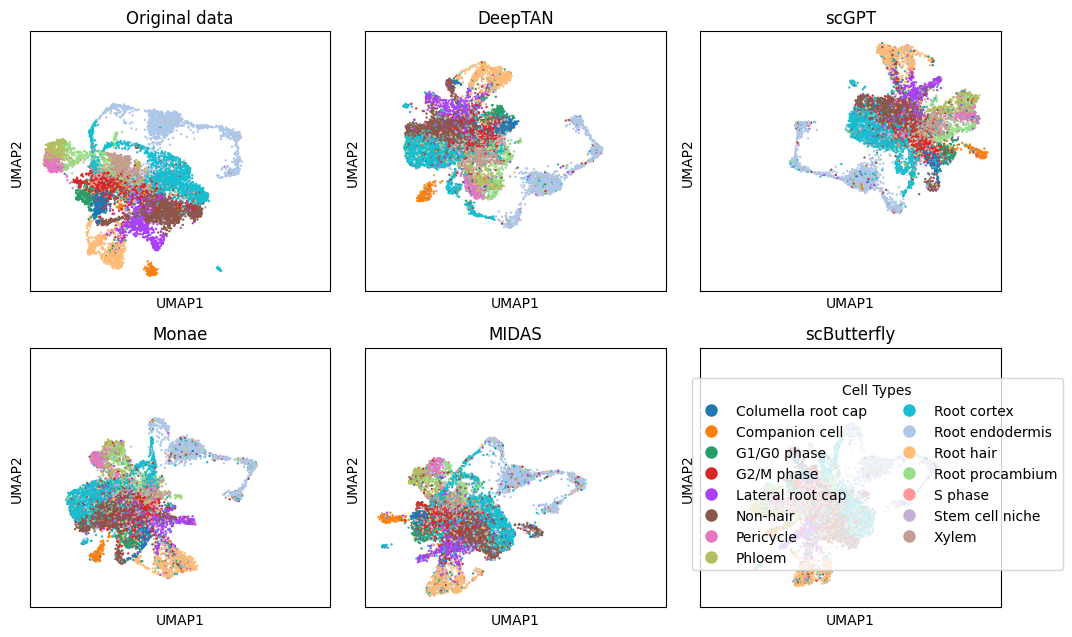

In [13]:
n_adata = len(adata_list)

# A4纸的宽度约为21厘米（8.27英寸），高度可以根据需要调整
a4_width_cm = 21
cm_to_inches = 0.393701
a4_width_inches = a4_width_cm * cm_to_inches

n_cols = 3  # 每行最多显示 3 个子图
n_rows = (n_adata + n_cols - 1) // n_cols

fig_height = 3.6 * n_rows  # 每行高度为 5

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(a4_width_inches * 1.3, fig_height),
    sharex=True,
    sharey=True,
)
if n_rows == 1:
    axes = axes.reshape(1, -1)

# 绘制每个文件的 UMAP 图
for i, _adata in enumerate(adata_list):
    row, col = i // n_cols, i % n_cols
    ax = axes[row, col]
    sc.pl.umap(
        _adata,
        color="Celltype",
        title=adata_names[i],
        show=False,
        ax=ax,
        legend_loc=None,
    )

# 如果子图数量不足，隐藏多余的子图
for i in range(n_adata, n_rows * n_cols):
    row, col = i // n_cols, i % n_cols
    axes[row, col].axis('off')

# 创建共享图例
legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=cell_type,
        markerfacecolor=color,
        markersize=10,
    )
    for cell_type, color in zip(
        all_cell_types, sc.pl.palettes.default_20[: len(all_cell_types)]
    )
]

fig.legend(handles=legend_elements, loc='lower right', title="Cell Types", ncol=2, bbox_to_anchor=(1, 0.09))

# 调整布局以避免重叠
plt.tight_layout(rect=(0, 0, 0.95, 0.9))  # 为图例留出空间

# 将图例放置在中间下方
# fig.legend(
#     handles=legend_elements,
#     loc="upper center",
#     bbox_to_anchor=(0.5, -0.05),
#     ncol=len(all_cell_types) // 2,
#     title="Cell Types",
# )

# 调整布局以避免重叠
# plt.tight_layout()

# 显示图像
plt.show()

### 可视化测试集样本

/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view 

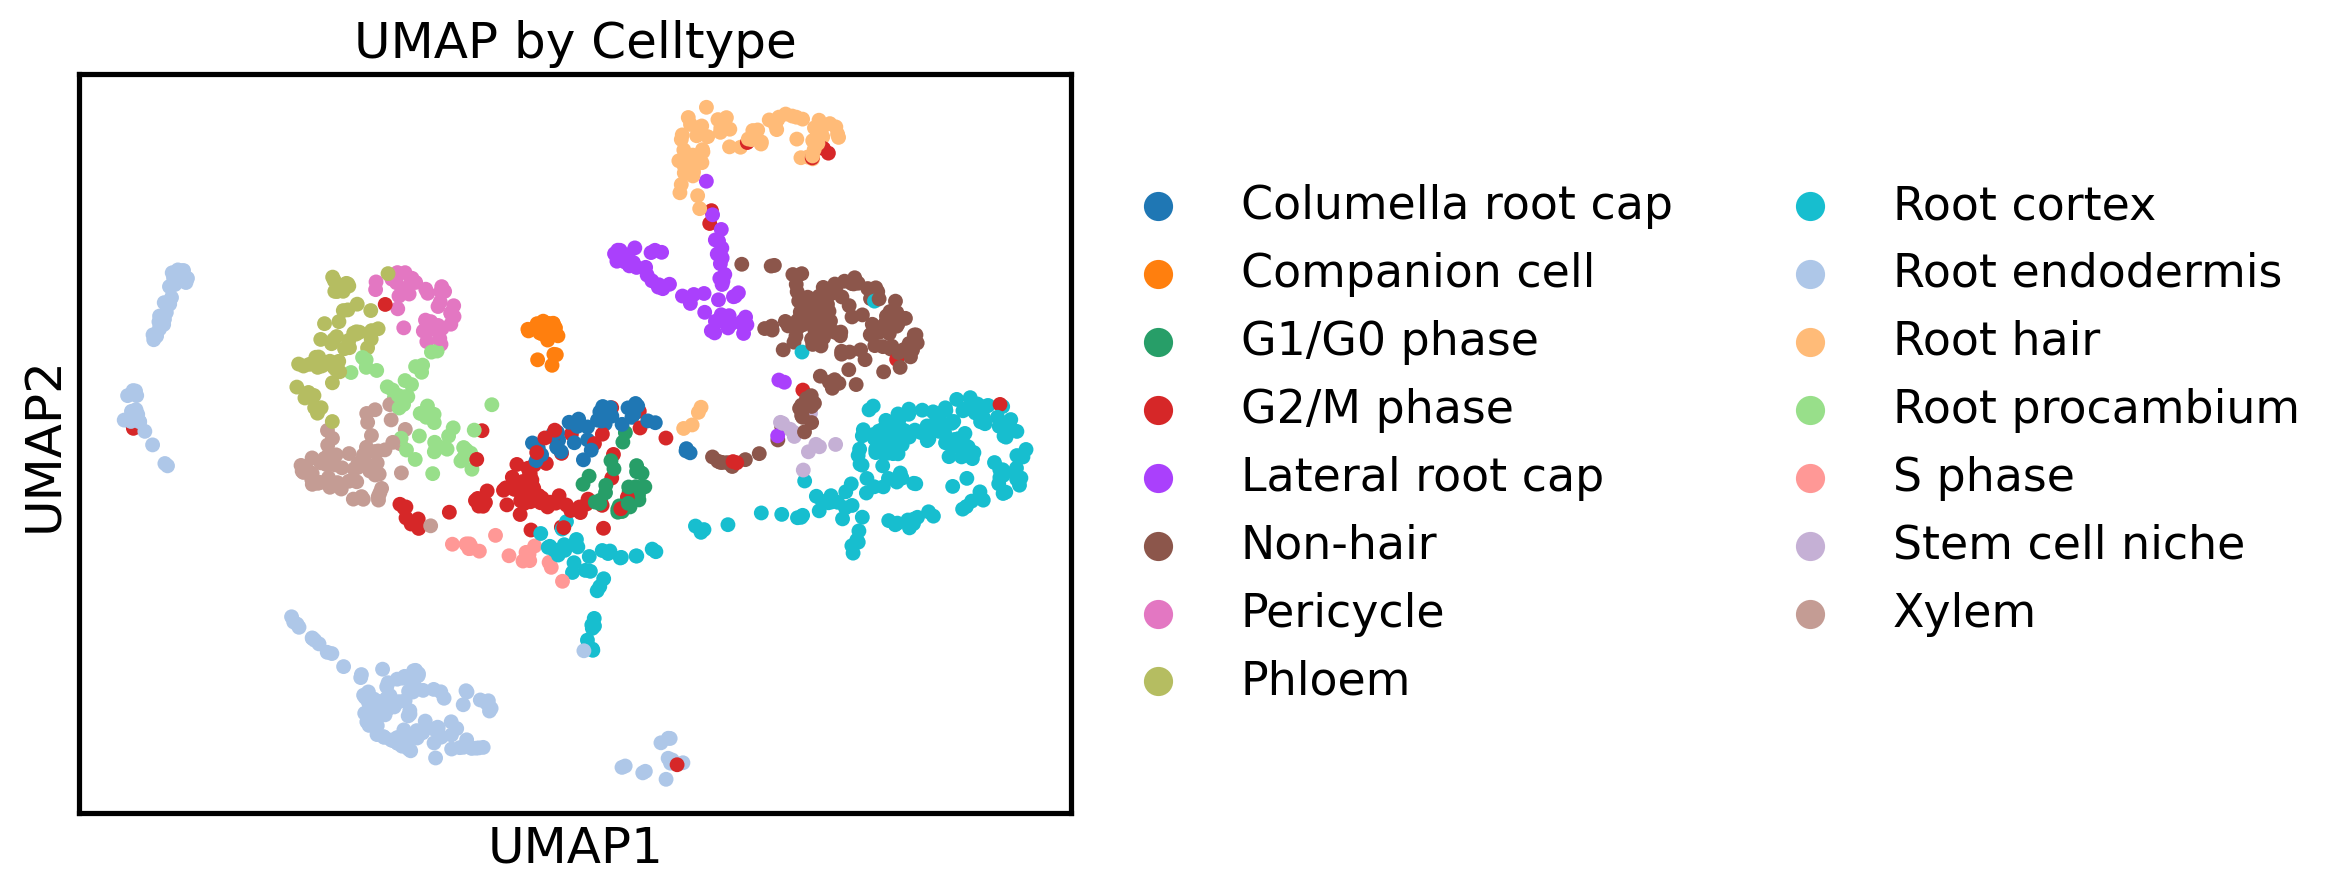

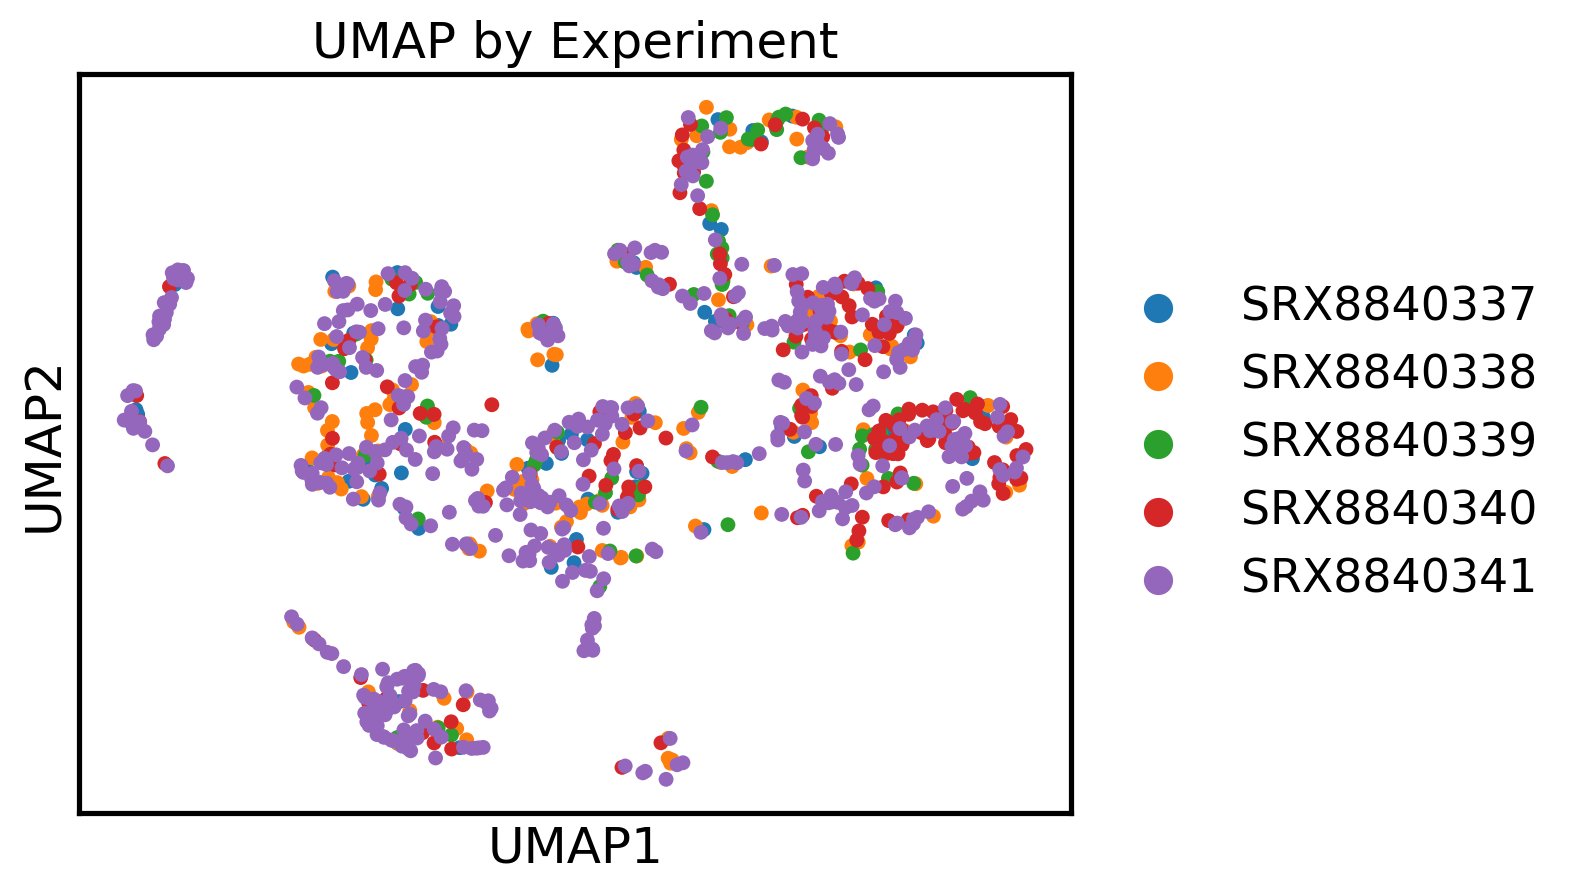

In [24]:
sc.pl.umap(adata_tst, color="Celltype", title="UMAP by Celltype")
sc.pl.umap(adata_tst, color="Orig.ident", title="UMAP by Experiment")

In [39]:
g_emb = results["g_embedding"]
print(g_emb.shape)

(1051, 256)


### UMAP 可视化

In [23]:
# UMAP 可视化 g_emb
import seaborn as sns
import umap

/home/wuch/miniforge3/envs/pyg/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
%config InlineBackend.figure_format = 'retina'
%config InlineBackend.figure_dpi = 300

/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/matplotlib_inline/config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


In [73]:
reducer = umap.UMAP()
# embeddings = reducer.fit_transform(g_emb)
embeddings = reducer.fit_transform(x_true+np.random.normal(0, 0.1, x_true.shape))
print(embeddings.shape)

(1051, 2)


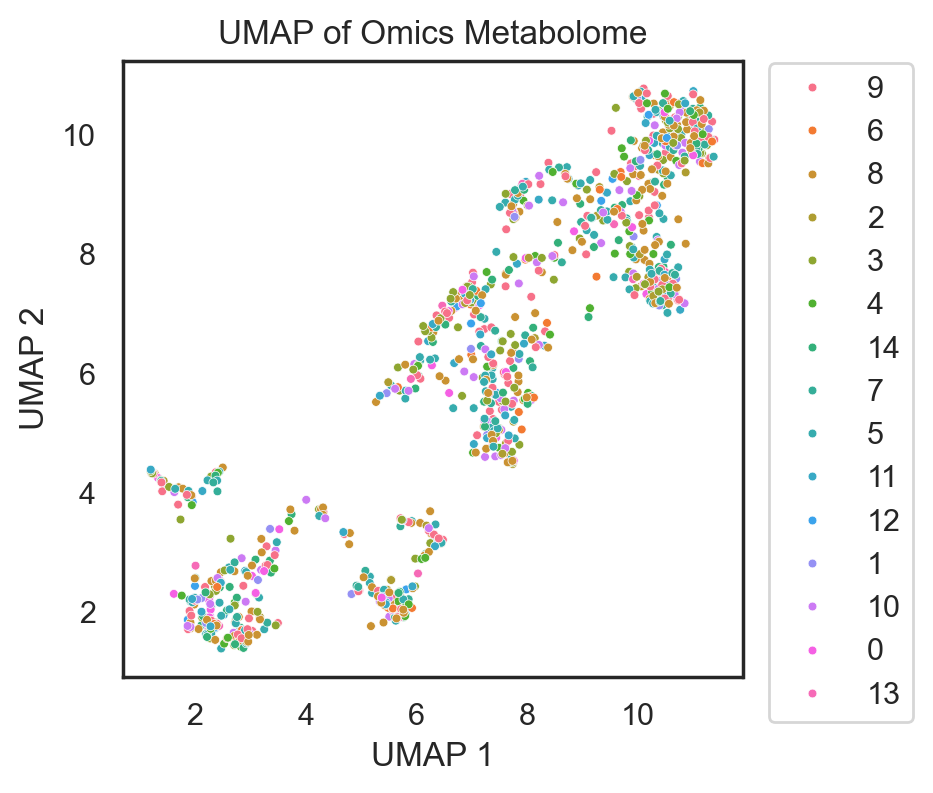

In [74]:
try:
    pic.figure.clear()
except:
    pass
sns.set_theme(style="white")
# Set small point size
pic = sns.scatterplot(x=embeddings[:, 0], y=embeddings[:, 1], hue=[str(i) for i in label_pred_debug], s=10)
pic.set_title('UMAP of Omics Metabolome')
pic.set_xlabel('UMAP 1')
pic.set_ylabel('UMAP 2')
# Put legend outside and right center. It should not overlap xlabels
pic.legend(loc='upper right', bbox_to_anchor=(1.3, 1.02))

pic.figure.set_size_inches(4, 4)

### Leiden 算法

In [13]:
silhouette_avg = silhouette_score(g_emb, label_pred.argmax(axis=1).flatten())
print(f"Silhouette Coefficient: {silhouette_avg}")

ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)